## Importar Librerias

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import subprocess
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Configuración y carga de datos

In [ ]:
# Nombres de los datasets
DATASETS = [
"ETTh1",
"ETTh2",
"ETTm1",
"ETTm2"
]

In [ ]:
# Configuración experimental:
INPUT_LENGTH = 96
HORIZONS = [24,48,96,192,336,720]
TARGET = "OT"

## Implementación del modelo

In [ ]:
# Definición de proceso para entrenamiento de modelo
def run_experiment(dataset, horizon):

    # Comando para ejecución en terminal
    command = f"""
    python ./Pyraformer/long_range_main.py \
    -data {dataset} \
    -root_path ./ETDataset/ETT-small/ \
    -data_path {dataset}.csv \
    -input_size 96 \
    -predict_step {horizon} \
    -epoch 5
    """
    # Ejecución en terminal
    process = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )
    print(process.stdout)
    print(process.stderr)

    return process.stdout + process.stderr

In [57]:
# Prueba de ejecución
log_prueba = run_experiment("ETTm1",24)
print(log_prueba)

[Info] parameters: Namespace(eval=False, data='ETTm1', root_path='./ETDataset/ETT-small/', data_path='ETTm1.csv', input_size=96, predict_step=24, inverse=False, model='Pyraformer', decoder='FC', epoch=5, batch_size=32, pretrain=False, hard_sample_mining=False, dropout=0.05, lr=0.0001, lr_step=0.1, d_model=512, d_inner_hid=512, d_k=128, d_v=128, d_bottleneck=128, n_head=4, n_layer=4, window_size=[4, 4, 4], inner_size=3, CSCM='Bottleneck_Construct', truncate=False, use_tvm=False, iter_num=5, enc_in=7, dec_in=7, covariate_size=4, seq_num=1, embed_type='DataEmbedding')
[Info] Number of parameters: 6994176
train 34441
test 11497
[ Epoch 1 ]
  - (Training) MSE:  0.24431elapse: 0.497 min
test shape:(11497, 24, 7)
Epoch 0, mse:0.3254452347755432, mae:0.3764142096042633, rmse:0.570478081703186, mape:1.943084955215454, mspe:186.72621154785156
[ Epoch 2 ]
  - (Training) MSE:  0.15669elapse: 0.573 min
test shape:(11497, 24, 7)
Epoch 1, mse:0.3336687386035919, mae:0.37366992235183716, rmse:0.577640

In [ ]:
# Lista de registros
logs = []

# Ejecutar pruebas para cada dataset con fiferentes horizontes
for dataset in DATASETS:
    for horizon in HORIZONS:

        # Mostrat prueba que se está ejecutando
        print("Running:", dataset, "Horizon:", horizon)

        # Entrenamiento
        output = run_experiment(dataset, horizon)

        # Almacenamiento de resultados
        logs.append({
            "dataset": dataset,
            "horizon": horizon,
            "log": output
        })

Running: ETTh1 Horizon: 24
[Info] parameters: Namespace(eval=False, data='ETTh1', root_path='./ETDataset/ETT-small/', data_path='ETTh1.csv', input_size=96, predict_step=24, inverse=False, model='Pyraformer', decoder='FC', epoch=5, batch_size=32, pretrain=False, hard_sample_mining=False, dropout=0.05, lr=0.0001, lr_step=0.1, d_model=512, d_inner_hid=512, d_k=128, d_v=128, d_bottleneck=128, n_head=4, n_layer=4, window_size=[4, 4, 4], inner_size=3, CSCM='Bottleneck_Construct', truncate=False, use_tvm=False, iter_num=5, enc_in=7, dec_in=7, covariate_size=4, seq_num=1, embed_type='DataEmbedding')
[Info] Number of parameters: 6994176
train 8521
test 2857
[ Epoch 1 ]
  - (Training) MSE:  0.44639elapse: 0.124 min
test shape:(2857, 24, 7)
Epoch 0, mse:0.524212121963501, mae:0.5127830505371094, rmse:0.7240249514579773, mape:9.757540702819824, mspe:32491.5390625
[ Epoch 2 ]
  - (Training) MSE:  0.30823elapse: 0.117 min
test shape:(2857, 24, 7)
Epoch 1, mse:0.4935104250907898, mae:0.49527469277381

## Graficas de entrenamiento

In [ ]:
results = []

# Almacenar los resultados de las métricas MSE y MAE de cada dataset
for item in logs:

    log = item["log"].lower()

    mse_match = re.search(r"mse[: ]+([0-9.]+)",log)
    mae_match = re.search(r"mae[: ]+([0-9.]+)",log)

    mse = float(mse_match.group(1)) if mse_match else None
    mae = float(mae_match.group(1)) if mae_match else None

    results.append([
        item["dataset"],
        item["horizon"],
        mse,
        mae
    ])

In [ ]:
# Dataframe para mostrar los resultados
results_df = pd.DataFrame(
    results,
    columns=["Dataset","Horizon","MSE","MAE"]
)
results_df

,Dataset,Horizon,MSE,MAE
0,ETTh1,24,0.44639,0.512783
1,ETTh1,48,0.48677,0.552792
2,ETTh1,96,0.52356,0.623932
3,ETTh1,192,0.54609,0.682340
4,ETTh1,336,0.54431,0.759408
5,ETTh1,720,0.54120,0.811113
6,ETTh2,24,0.34966,0.582370
7,ETTh2,48,0.39853,0.660783
8,ETTh2,96,0.43870,1.025616
9,ETTh2,192,0.47753,1.748685


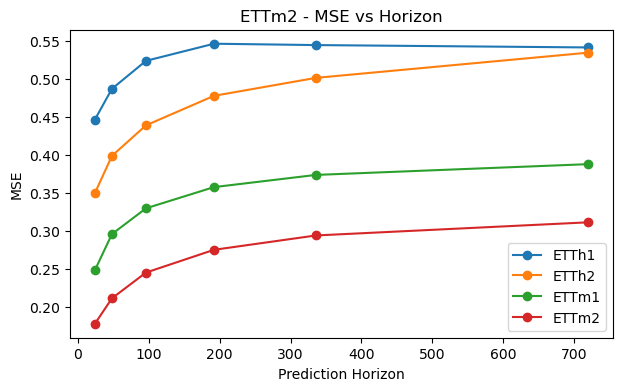

In [ ]:
# Gráfica MSE vs horizonte
plt.figure(figsize=(7,4))
for dataset in results_df["Dataset"].unique():
    subset = results_df[results_df["Dataset"]==dataset]
    plt.plot(subset["Horizon"], subset["MSE"], marker="o", label=dataset)

plt.title(dataset + " - MSE vs Horizon")
plt.xlabel("Prediction Horizon")
plt.ylabel("MSE")
plt.legend()
plt.savefig(fname="MSEvsHorizon", dpi=800, format="png")
plt.show()


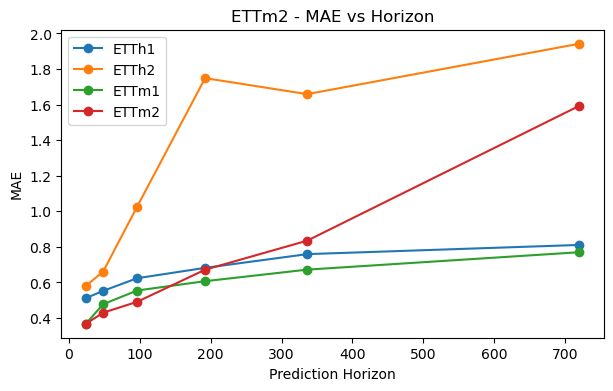

In [ ]:
# Gráfica MAE vs horizonte
plt.figure(figsize=(7,4))

for dataset in results_df["Dataset"].unique():
    subset = results_df[results_df["Dataset"]==dataset]
    plt.plot(subset["Horizon"], subset["MAE"], marker="o", label=dataset)

plt.title(dataset + " - MAE vs Horizon")
plt.xlabel("Prediction Horizon")
plt.ylabel("MAE")
plt.legend()
plt.savefig(fname="MAEvsHorizon", dpi=800, format="png")
plt.show()

## Pruebas y resultados obtenidos

In [ ]:
# Guardar resultados en un archivo csv
results_df.to_csv("pyraformer_results.csv", index=False)

In [ ]:
# Función para ejecutar entrenamiento con variaciones de hiperparámetros
def run_experiment(dataset, horizon, epoch,lr):

    # Comando para ejecución en terminal
    command = f"""
    python ./Pyraformer/long_range_main.py \
    -data {dataset} \
    -root_path ./ETDataset/ETT-small/ \
    -data_path {dataset}.csv \
    -input_size 96 \
    -predict_step {horizon} \
    -epoch {epoch} \
    -lr {lr}
    """
    # Ejecución en terminal
    process = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )
    print(process.stdout)
    print(process.stderr)

    return process.stdout + process.stderr

In [ ]:
# Entrenamiento con prueba de hiperparámetros
DATASET = "ETTh1"
HORIZONS = [24,48,96,192,336,720]
EPOCHS_LIST = [3,7]
LR_LIST = [0.01,0.0005]
test_logs = []
for horizon in HORIZONS:
    for epoch in EPOCHS_LIST:
        for lr in LR_LIST:
            print("Running:", DATASET, "Horizon:", horizon)

            # Entrenamiento
            output = run_experiment(DATASET, horizon, epoch, lr)

            # Almacenamiento de resultados
            logs.append({
                "dataset": DATASET,
                "horizon": horizon,
                "epoch": epoch,
                "lr": lr,
                "log": output
            })

Running: ETTh1 Horizon: 24
[Info] parameters: Namespace(eval=False, data='ETTh1', root_path='./ETDataset/ETT-small/', data_path='ETTh1.csv', input_size=96, predict_step=24, inverse=False, model='Pyraformer', decoder='FC', epoch=3, batch_size=32, pretrain=False, hard_sample_mining=False, dropout=0.05, lr=0.01, lr_step=0.1, d_model=512, d_inner_hid=512, d_k=128, d_v=128, d_bottleneck=128, n_head=4, n_layer=4, window_size=[4, 4, 4], inner_size=3, CSCM='Bottleneck_Construct', truncate=False, use_tvm=False, iter_num=5, enc_in=7, dec_in=7, covariate_size=4, seq_num=1, embed_type='DataEmbedding')
[Info] Number of parameters: 6994176
train 8521
test 2857
[ Epoch 1 ]
  - (Training) MSE:  3.63184elapse: 0.122 min
test shape:(2857, 24, 7)
Epoch 0, mse:1.2294307947158813, mae:0.8664247393608093, rmse:1.1087969541549683, mape:9.176640510559082, mspe:25648.783203125
[ Epoch 2 ]
  - (Training) MSE:  1.08100elapse: 0.115 min
test shape:(2857, 24, 7)
Epoch 1, mse:1.0949478149414062, mae:0.7907199263572

In [79]:
test_results = []

# Almacenar los resultados de las métricas MSE y MAE de cada dataset
for item in logs:

    # Pasar resultados a minúsculas
    log = item["log"].lower()

    # Buscar resultados
    mse_match = re.search(r"mse[: ]+([0-9.]+)",log)
    mae_match = re.search(r"mae[: ]+([0-9.]+)",log)
    epoch_match = re.search(r"epoch[=]+([0-9.]+)",log)
    lr_match = re.search(r"lr[=]+([0-9.]+)",log)
    mse = float(mse_match.group(1)) if mse_match else None
    mae = float(mae_match.group(1)) if mae_match else None
    epoch = int(epoch_match.group(1)) if epoch_match else None
    lr = float(lr_match.group(1)) if lr_match else None

    # Almacenar resultados
    test_results.append([
        item["dataset"],
        item["horizon"],
        epoch,
        lr,
        mse,
        mae
    ])

In [81]:
# Dataframe con resultados
test_results_df = pd.DataFrame(
    test_results,
    columns=["Dataset","Horizon","Epochs","LR", "MSE","MAE"]
)


In [108]:
test_results_df.sort_values(by=["Epochs"])


,Dataset,Horizon,Epochs,LR,MSE,MAE
0,ETTh1,24,3,0.0100,3.63184,0.866425
1,ETTh1,24,3,0.0005,0.41592,0.564610
21,ETTh1,720,3,0.0005,0.47666,0.748433
20,ETTh1,720,3,0.0100,3.48887,0.850682
4,ETTh1,48,3,0.0100,2.76731,0.878115
5,ETTh1,48,3,0.0005,0.44318,0.575827
8,ETTh1,96,3,0.0100,3.74093,0.907401
9,ETTh1,96,3,0.0005,0.46759,0.707665
17,ETTh1,336,3,0.0005,0.49075,0.743944
16,ETTh1,336,3,0.0100,3.21047,0.915208


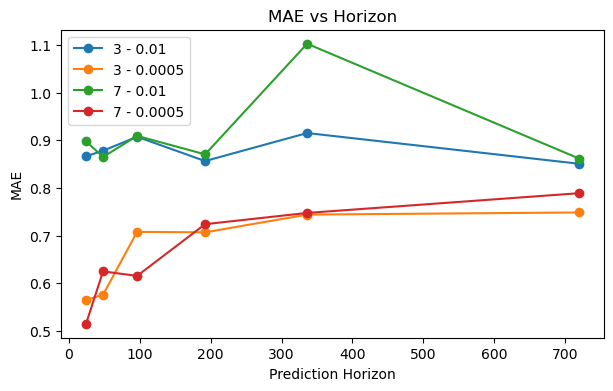

In [119]:
# Gráfica MAE vs horizonte
plt.figure(figsize=(7,4))

for epoch in test_results_df["Epochs"].unique():
    subset=test_results_df[test_results_df["Epochs"]==epoch]
    for lr in test_results_df["LR"].unique():
        l_subset=subset[subset["LR"]==lr]    
        plt.plot(l_subset["Horizon"], l_subset["MAE"], marker="o", label=str(epoch)+" - "+str(lr))

plt.title("MAE vs Horizon")
plt.xlabel("Prediction Horizon")
plt.ylabel("MAE")
plt.legend()
plt.savefig(fname="MAEvsHorizon_test", dpi=800, format="png")
plt.show()

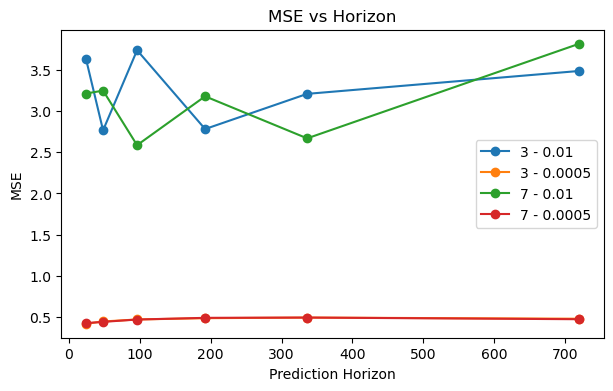

In [120]:
# Gráfica MAE vs horizonte
plt.figure(figsize=(7,4))

for epoch in test_results_df["Epochs"].unique():
    subset=test_results_df[test_results_df["Epochs"]==epoch]
    for lr in test_results_df["LR"].unique():
        l_subset=subset[subset["LR"]==lr]    
        plt.plot(l_subset["Horizon"], l_subset["MSE"], marker="o", label=str(epoch)+" - "+str(lr))

plt.title("MSE vs Horizon")
plt.xlabel("Prediction Horizon")
plt.ylabel("MSE")
plt.legend()
plt.savefig(fname="MSEvsHorizon_test", dpi=800, format="png")
plt.show()